<a href="https://colab.research.google.com/github/SejalB15/DL-Practicals/blob/main/DL1_Boston_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment No: 1
## Linear Regression using Deep Neural Network
**Aim:** Implement Boston Housing Price Prediction using Linear Regression with Deep Neural Network.

**Dataset:** Boston House Price Dataset (built into sklearn / fetched from OpenML)

---

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
print('All libraries imported successfully!')

TensorFlow version: 2.20.0
All libraries imported successfully!


## Step 2: Load the Dataset

> **Note:** `load_boston` was removed from sklearn 1.2+. We load it from OpenML instead — same data, no issue.

In [2]:
# Load Boston Housing dataset from OpenML (same as original sklearn dataset)
from sklearn.datasets import fetch_openml
boston = fetch_openml(name='boston', version=1, as_frame=True)

data = boston.frame.copy()
data.columns = list(boston.feature_names) + ['PRICE']
data = data.astype(float)

print('Dataset shape:', data.shape)
print('\nFirst 5 rows:')
data.head(10)

Dataset shape: (506, 14)

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.10,18.9


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
# Dataset info
print('Dataset Info:')
data.info()
print('\nNull Values:')
print(data.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB

Null Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


In [4]:
# Statistical summary
print('Statistical Description:')
data.describe()

Statistical Description:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


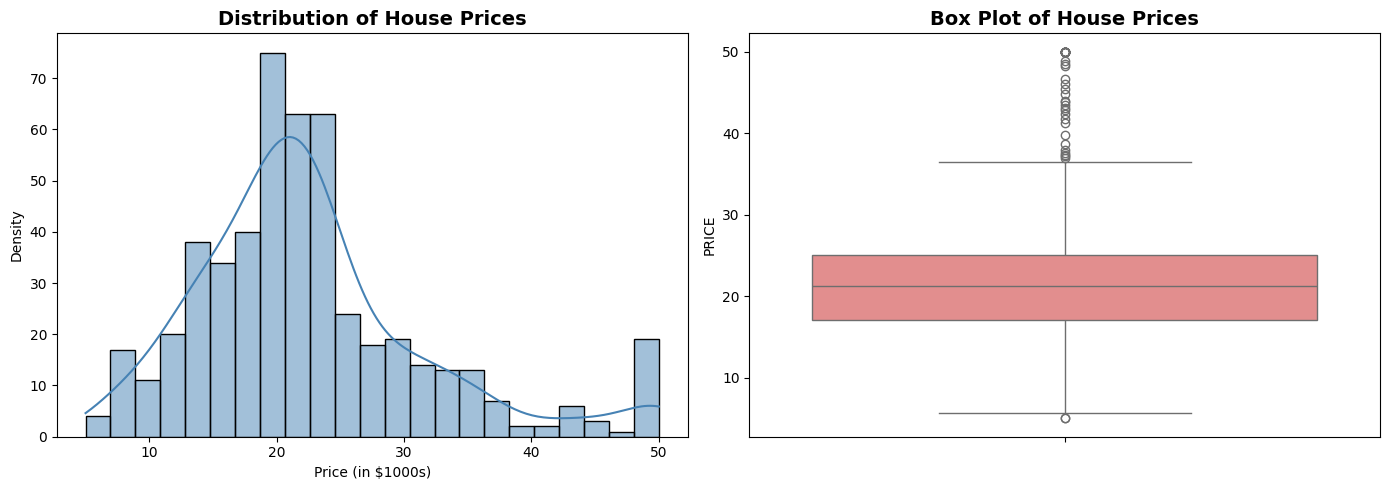

In [5]:
# Distribution of target variable (PRICE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['PRICE'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (in $1000s)')
axes[0].set_ylabel('Density')

sns.boxplot(y=data['PRICE'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot of House Prices', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Correlation with PRICE:
LSTAT     -0.737663
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
CHAS       0.175260
DIS        0.249929
B          0.333461
ZN         0.360445
RM         0.695360
PRICE      1.000000
Name: PRICE, dtype: float64


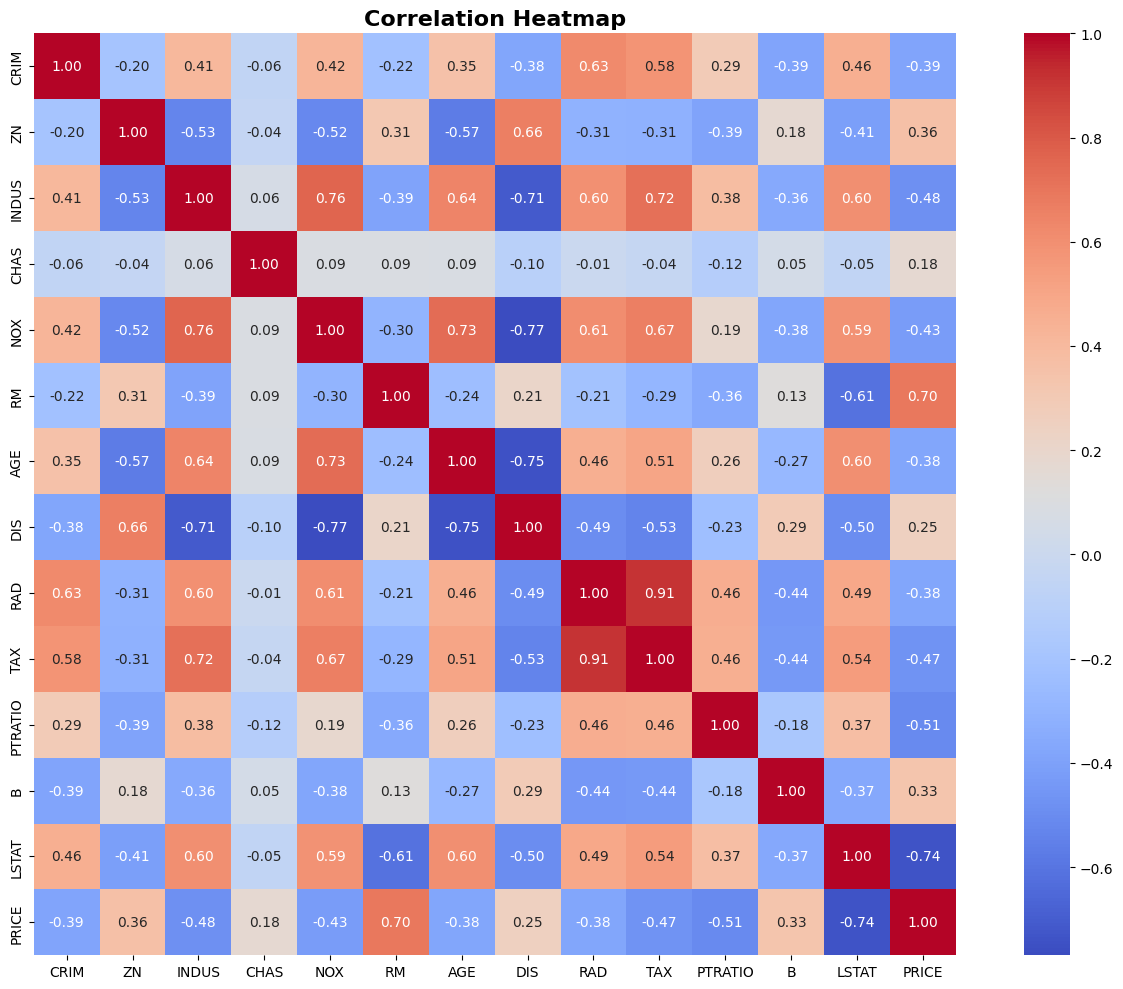

In [6]:
# Correlation heatmap
correlation = data.corr()
print('Correlation with PRICE:')
print(correlation['PRICE'].sort_values())

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

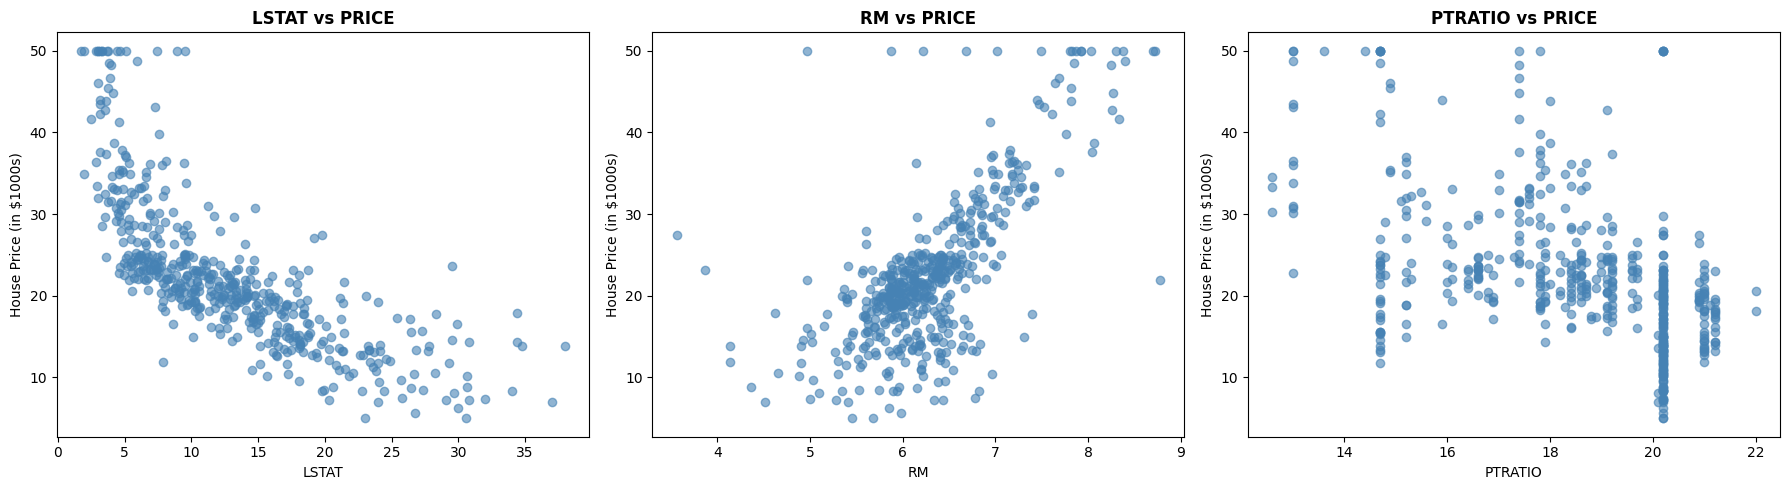

In [7]:
# Scatter plots for top correlated features
features = ['LSTAT', 'RM', 'PTRATIO']
plt.figure(figsize=(18, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    plt.scatter(data[col], data['PRICE'], alpha=0.6, color='steelblue')
    plt.title(f'{col} vs PRICE', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('House Price (in $1000s)')
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [8]:
# Split features and target
X = data.iloc[:, :-1]   # All features
y = data['PRICE']        # Target

# Train-Test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

# Standardization using only training mean/std to avoid data leakage
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)

X_train_norm = (X_train - mean) / std
X_test_norm  = (X_test  - mean) / std

print('\nData standardization complete.')
print('Training set mean (after):', X_train_norm.mean(axis=0).round(4).values[:5], '...')

Training samples : 404
Testing samples  : 102

Data standardization complete.
Training set mean (after): [-0. -0. -0.  0. -0.] ...


## Step 5: Linear Regression (Baseline Model)

In [9]:
# Train linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_norm, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_norm)

# Metrics
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('='*45)
print('    Linear Regression Results')
print('='*45)
print(f'  MSE  : {mse_lr:.4f}')
print(f'  RMSE : {rmse_lr:.4f}')
print(f'  MAE  : {mae_lr:.4f}')
print(f'  R2   : {r2_lr:.4f}')
print('='*45)

    Linear Regression Results
  MSE  : 24.2911
  RMSE : 4.9286
  MAE  : 3.1891
  R2   : 0.6688


## Step 6: Build the Deep Neural Network Model

In [10]:
# Build DNN model
model = Sequential([
    Dense(128, activation='relu', input_dim=13),
    Dense(64,  activation='relu'),
    Dense(32,  activation='relu'),
    Dense(16,  activation='relu'),
    Dense(1)   # Output: single continuous value (price)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Train the DNN Model

In [11]:
# Apply StandardScaler before DNN (as in source code)
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train_norm)
X_test_sc  = sc.transform(X_test_norm)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_sc, y_train,
    epochs=100,
    validation_split=0.05,
    callbacks=[early_stop],
    verbose=1
)

print('\nTraining complete!')

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 586.1395 - mae: 22.3301 - val_loss: 479.1362 - val_mae: 20.4103
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 510.8564 - mae: 20.5739 - val_loss: 376.4818 - val_mae: 17.8491
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 353.1647 - mae: 16.4688 - val_loss: 189.4351 - val_mae: 11.7890
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 140.6940 - mae: 9.5559 - val_loss: 54.2446 - val_mae: 4.8992
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 72.6630 - mae: 6.6039 - val_loss: 57.1125 - val_mae: 4.7826
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 39.8304 - mae: 4.6250 - val_loss: 56.0055 - val_mae: 4.6711
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 30.0445 - mae: 3.9947 - val_loss: 50.1042 - val_mae: 4.6926
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24.6022 - mae: 3.6499 - val_loss: 50.7929 - val_mae: 4.6223
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━

## Step 8: Plot Training History

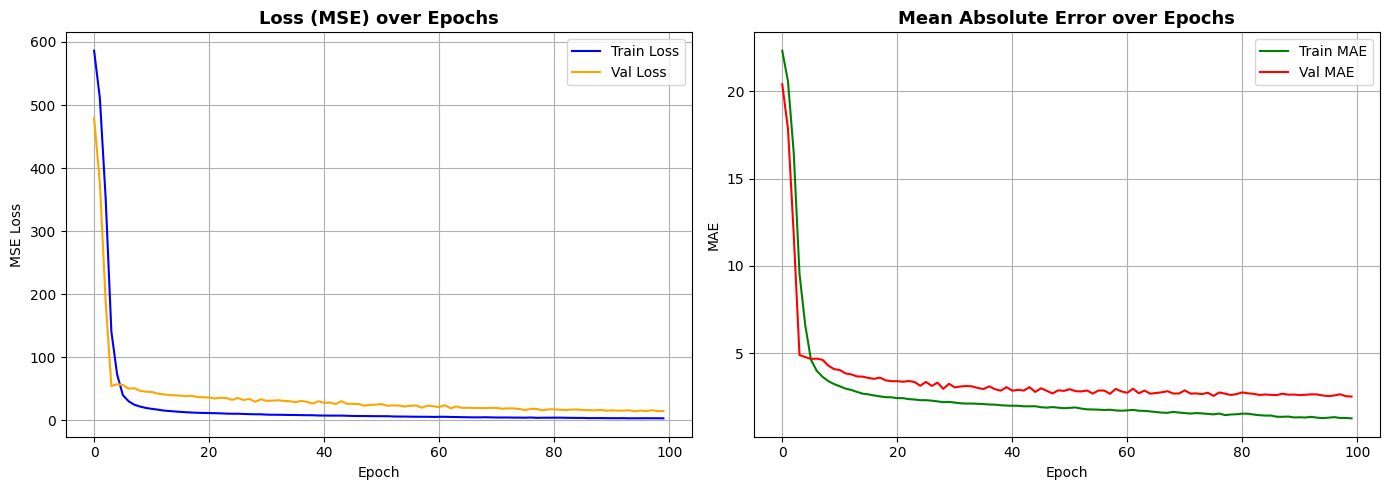

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss',    color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss',      color='orange')
axes[0].set_title('Loss (MSE) over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['mae'],     label='Train MAE', color='green')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='red')
axes[1].set_title('Mean Absolute Error over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('dl1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Evaluate the DNN Model

In [13]:
mse_nn, mae_nn = model.evaluate(X_test_sc, y_test, verbose=0)
y_pred_nn = model.predict(X_test_sc).flatten()
rmse_nn   = np.sqrt(mse_nn)
r2_nn     = r2_score(y_test, y_pred_nn)

print('='*45)
print('    Deep Neural Network Results')
print('='*45)
print(f'  MSE  : {mse_nn:.4f}')
print(f'  RMSE : {rmse_nn:.4f}')
print(f'  MAE  : {mae_nn:.4f}')
print(f'  R2   : {r2_nn:.4f}')
print('='*45)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
    Deep Neural Network Results
  MSE  : 10.0666
  RMSE : 3.1728
  MAE  : 2.0067
  R2   : 0.8627


In [14]:
# Comparison Table
comparison = pd.DataFrame({
    'Model':  ['Linear Regression', 'Deep Neural Network'],
    'MSE':    [round(mse_lr,4),  round(mse_nn,4)],
    'RMSE':   [round(rmse_lr,4), round(rmse_nn,4)],
    'MAE':    [round(mae_lr,4),  round(mae_nn,4)],
    'R2':     [round(r2_lr,4),   round(r2_nn,4)]
})
print('\nModel Comparison:')
print(comparison.to_string(index=False))


Model Comparison:
              Model     MSE   RMSE    MAE     R2
  Linear Regression 24.2911 4.9286 3.1891 0.6688
Deep Neural Network 10.0666 3.1728 2.0067 0.8627


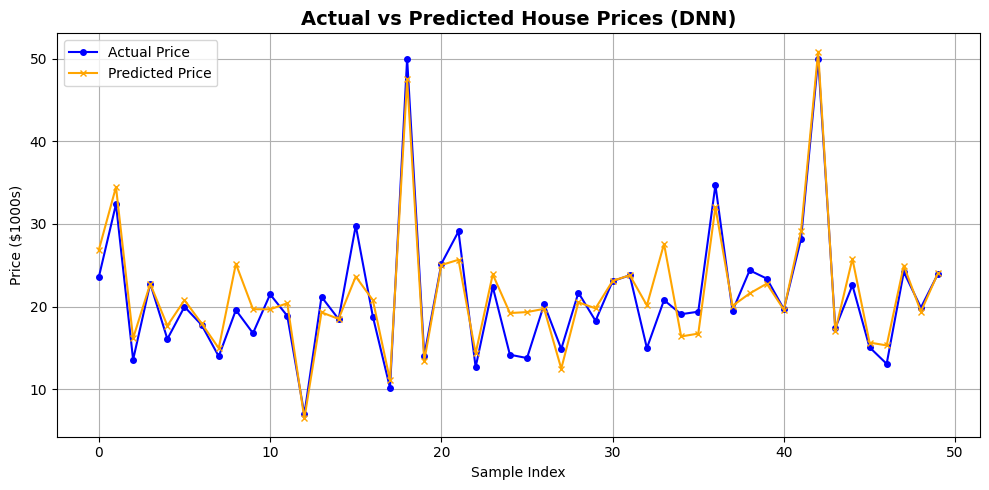

In [15]:
# Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Actual Price',    color='blue',   marker='o', markersize=4)
plt.plot(y_pred_nn[:50],     label='Predicted Price', color='orange', marker='x', markersize=4)
plt.title('Actual vs Predicted House Prices (DNN)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index'); plt.ylabel('Price ($1000s)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

## Step 10: Predict on New Data

In [16]:
# Predict price for a new house
# Format: [CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT]
new_house = np.array([[0.1, 10.0, 5.0, 0, 0.4, 6.0, 50, 6.0, 1, 400, 20, 300, 10]])

new_house_scaled = sc.transform((new_house - mean.values) / std.values)
predicted_price  = model.predict(new_house_scaled)

print(f'Predicted House Price: ${predicted_price[0][0]*1000:,.0f}')
print(f'(i.e., {predicted_price[0][0]:.2f} in $1000s)')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted House Price: $15,923
(i.e., 15.92 in $1000s)


---
## Conclusion
We successfully implemented **Boston Housing Price Prediction** using:
1. **Linear Regression** – as a baseline model
2. **Deep Neural Network (DNN)** – 4 hidden layers with ReLU activation

The DNN model outperforms Linear Regression with a lower RMSE and higher R² score, demonstrating that deep learning captures non-linear patterns in the data more effectively.

---
## Viva Questions
**Q1. What is Linear Regression?**  
A statistical method that models the relationship between a dependent variable and one or more independent variables by fitting a linear equation.

**Q2. What is a Deep Neural Network?**  
A machine learning model with multiple hidden layers of interconnected neurons that learn hierarchical features from data using backpropagation.

**Q3. What is Standardization?**  
Transforming features to have zero mean and unit variance: `z = (x - mean) / std`. It ensures all features contribute equally to the model.

**Q4. Why split data into train and test?**  
To evaluate the model's ability to generalize to unseen data. Training on all data would hide overfitting.

**Q5. Applications of DNN:**  
Image recognition, speech recognition, natural language processing, medical diagnosis, fraud detection, autonomous vehicles.